# Exploration of PyAgrum

In [1]:
import matplotlib.pyplot as plt
import pyagrum as gum
import pyagrum.lib.notebook as gnb

## Water sprinkler

In [2]:
bn = gum.BayesNet("WaterSprinkler")

# Create the nodes
c = bn.add(gum.LabelizedVariable('c', 'cloudy ?', 2))
s = bn.add(gum.LabelizedVariable('s', 'sprinkler ?', 2))
r = bn.add(gum.LabelizedVariable('r', 'rain ?', 2))
w = bn.add(gum.LabelizedVariable('w', 'wet grass ?', 2))

# Add the edges
for link in [(c,s), (c,r), (r, w), (s, w)]:
    bn.addArc(*link)

# Define the CPTs
bn.cpt(c).fillWith([0.4, 0.6])  # p(c=0) = 0.4, p(c=1) = 0.6

bn.cpt(s)[{'c': 0}] = [0.5, 0.5]
bn.cpt(s)[{'c': 1}] = [0.9, 0.1]

bn.cpt(r)[{'c': 0}] = [0.8, 0.2]
bn.cpt(r)[{'c': 1}] = [0.2, 0.8]

bn.cpt(w)[{'r': 0, 's': 0}] = [1, 0]
bn.cpt(w)[{'r': 0, 's': 1}] = [0.1, 0.9]
bn.cpt(w)[{'r': 1, 's': 0}] = [0.1, 0.9]
bn.cpt(w)[{'r': 1, 's': 1}] = [0.01, 0.99]

In [3]:
gum.config["notebook", "tensor_visible_digits"] = 2
gnb.sideBySide(bn.cpt("c"), captions=["$P(Cloudy)$"])
gnb.sideBySide(bn.cpt("s"), gnb.getBN(bn, size="3!"), bn.cpt("r"))
gnb.sideBySide(bn.cpt("w"))
#gnb.showBN(bn, size=9)

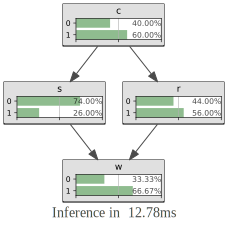

In [4]:
# Bayes net with no evidence
gnb.showInference(bn, evs={})

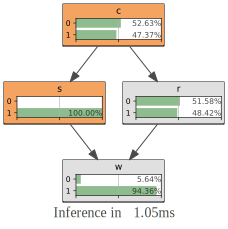

In [5]:
# Bayes net with hard and soft evidence
gnb.showInference(bn, evs={'s': '1', 'c': [0.3, 0.9]})

In [6]:
ie = gum.LazyPropagation(bn)
ie.setEvidence({'s': 0})
ie.makeInference()
ie.posterior("w")[1]

0.5740540540540541